# Question 2: Resume Analysis

**Overview:**
- looks over resume data from my resume and the classes resume to identify the most common words, specific words and unique words within the resumes

**Analysis**
- Reads my resume and gets list of resume words
- plots histogram of top 20 resume words
- remove stop words from resume words and creates specific words
- read all resumes in class resumes and get resume words for class
- plot histogram of top 20 class resume words
- remove stop words to create specific resume words for class
- analyze specific words from class and from my resume to find words unique to myself

**Section 1: setup**

In [6]:
# Set up
import os
import re
from collections import Counter
import matplotlib.pyplot as plt
import PyPDF2
# Paths
MY_RESUME_DIR = "MyResume"
CLASS_RESUME_DIR = "ClassResume"
STOP_WORDS_FILE = "Stop_Words.txt"

**Section 2: Helping functions**
- gets data from path
- gets stop words
- extract words
- create plot
- saves words

In [7]:
def extract_text_from_pdf(path):
    text = ""
    try:
        with open(path, 'rb') as file:
            reader = PyPDF2.PdfReader(file)
            for page in reader.pages:
                text += page.extract_text()
    except Exception as e:
        print(f"Error. {path}: {e}")
    return text

def load_stop_words(path):
    stop_words = set()
    if os.path.exists(path):
        with open(path, 'r') as f:
            stop_words = set(word.strip().lower() for word in f)
    return stop_words

def tokenize(text):
    words = re.findall(r'[a-zA-Z]+', text.lower())
    return words

def get_words_from_directory(directory):
    all_words = []
    if os.path.exists(directory):
        for filename in os.listdir(directory):
            if filename.endswith('.pdf'):
                path = os.path.join(directory, filename)
                text = extract_text_from_pdf(path)
                words = tokenize(text)
                all_words.extend(words)
    return all_words

def plot_top_words(word_counts, title, n=20):
    top_words = word_counts.most_common(n)
    if top_words:
        words, counts = zip(*top_words)
        plt.figure(figsize=(10, 6))
        plt.bar(range(len(words)), counts)
        plt.xticks(range(len(words)), words, rotation=45, ha='right')
        plt.title(title)
        plt.xlabel('Words')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

def save_word_counts(word_counts, filename):
    with open(filename, 'w') as f:
        for word, count in word_counts.most_common():
            f.write(f"{word},{count}\n")

**Section 3: My Resume Analysis**
- exact words and analyze words
- get 20 most used words
- get amount of words
- get unique words
- get specific words and count
- Histograms

Total words in resume: 320
unique words in resume: 229


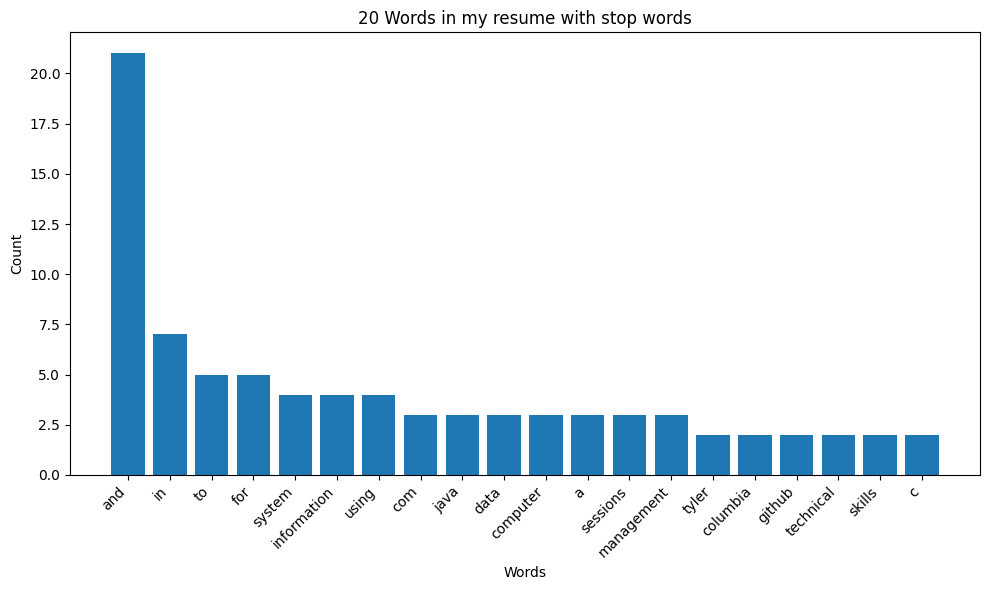


Words without stop words: 268
Unique words: 216


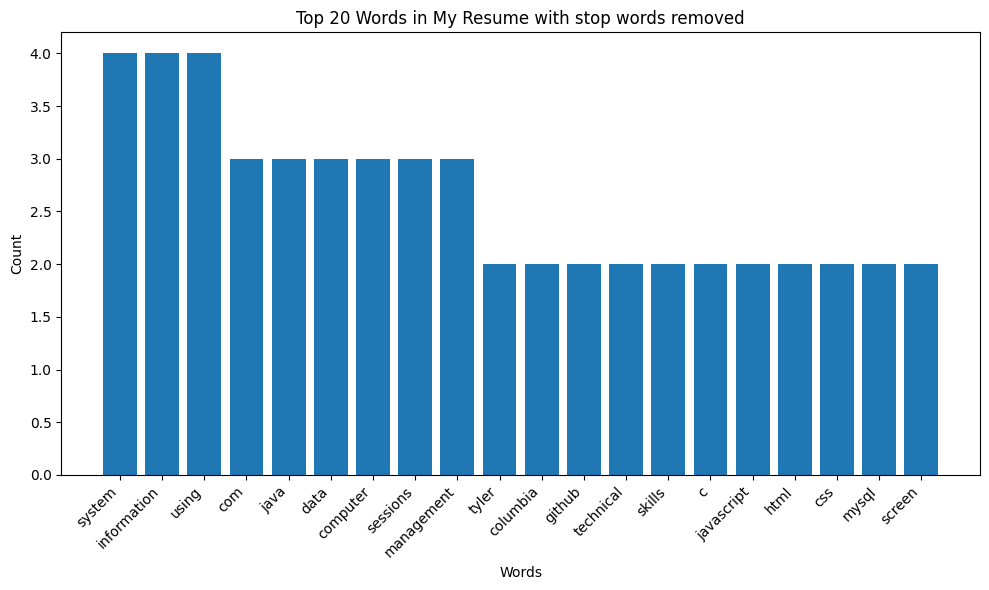

In [8]:
# Analze MyResume
my_resume_words = get_words_from_directory(MY_RESUME_DIR)
resume_word_counts = Counter(my_resume_words)

print(f"Total words in resume: {len(my_resume_words)}")
print(f"unique words in resume: {len(resume_word_counts)}")

plot_top_words(resume_word_counts, "20 Words in my resume with stop words")
save_word_counts(resume_word_counts, "Resume_Words_Tyler.txt")

stop_words = load_stop_words(STOP_WORDS_FILE)
specific_words = [word for word in my_resume_words if word not in stop_words]
specific_word_counts = Counter(specific_words)

print(f"\nWords without stop words: {len(specific_words)}")
print(f"Unique words: {len(specific_word_counts)}")

plot_top_words(specific_word_counts, "Top 20 Words in My Resume with stop words removed")
save_word_counts(specific_word_counts, "Specific_Words_Tyler.txt")

**Section 4: Class Resume Analysis**
- Analyze class resumes in ClassResume folder
- Get 20 most used words
- Get Word count
- Get class specific words and counts
- plot histogram

total words in class resumes: 8318
Unique words: 2458


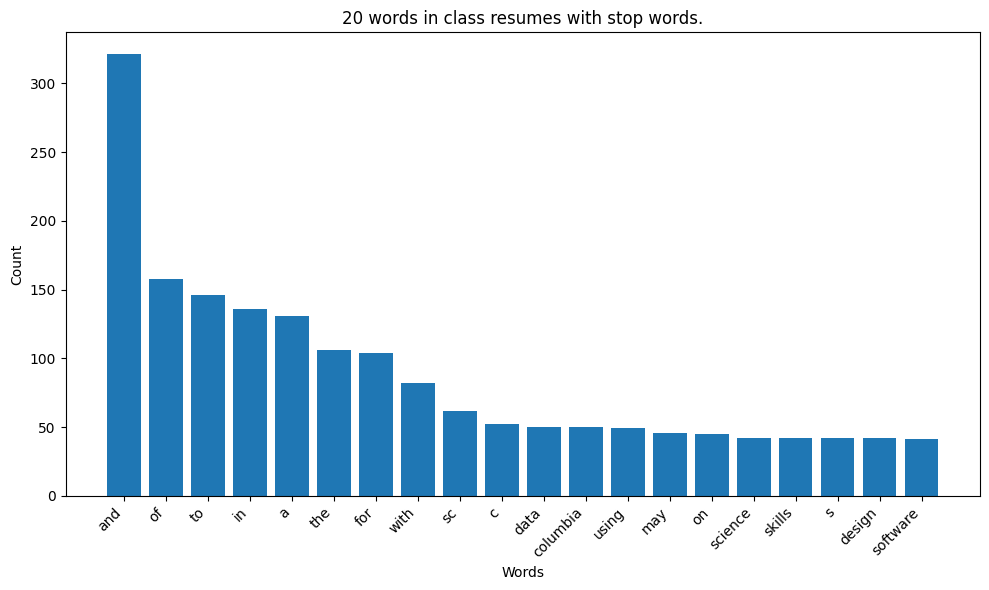


Words after removing stop words: 6765
Unique specific words: 2397


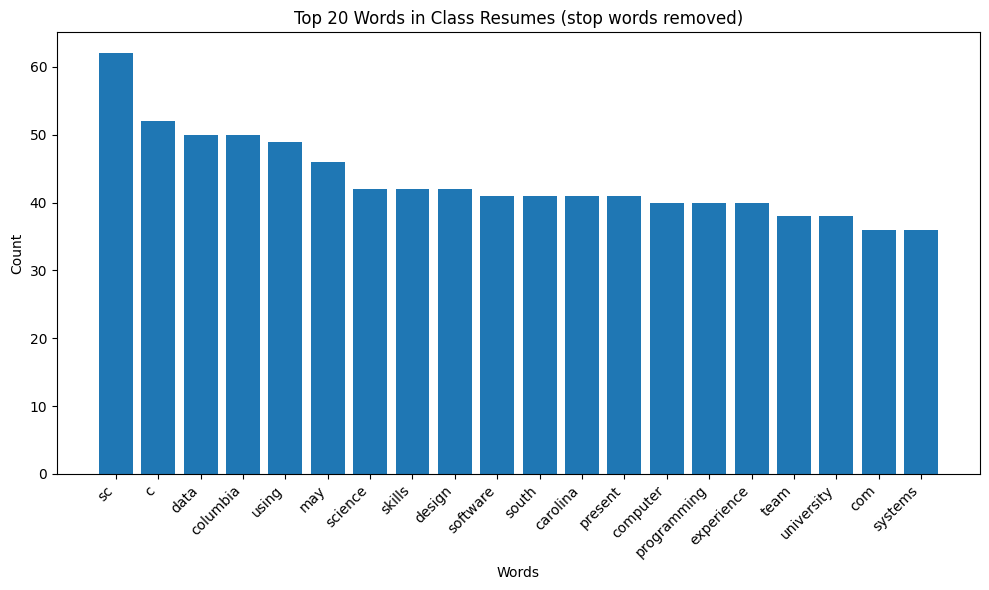

In [9]:
# Analyze class resume
class_resume_words = get_words_from_directory(CLASS_RESUME_DIR)
class_word_counts = Counter(class_resume_words)

print(f"total words in class resumes: {len(class_resume_words)}")
print(f"Unique words: {len(class_word_counts)}")

plot_top_words(class_word_counts, "20 words in class resumes with stop words.")
save_word_counts(class_word_counts, "Resume_Words_Class.txt")

class_specific_words = [word for word in class_resume_words if word not in stop_words]
class_specific_counts = Counter(class_specific_words)

print(f"\nWords after removing stop words: {len(class_specific_words)}")
print(f"Unique specific words: {len(class_specific_counts)}")

plot_top_words(class_specific_counts, "Top 20 Words in Class Resumes (stop words removed)")
save_word_counts(class_specific_counts, "Specific_Words_Class.txt")

**Section 5: Analyze Unique Specific words from class and myself**
- find what words I use in my resume that are unique to myself that I use

In [10]:
# Getting unique words
my_words_set = set(specific_word_counts.keys())
class_words_set = set(class_specific_counts.keys())

unique_to_me = my_words_set - class_words_set
unique_sorted = sorted(unique_to_me)

print(f"unique Specific words inside of my resume from comparing to unique specific words from class resumes: {len(unique_to_me)}")
print("\n20 unique words:")
print(unique_sorted[:20])

# Save unique words
with open("Unique_Specific_Words_Tyler.txt", 'w') as f:
    for word in unique_sorted:
        f.write(f"{word}\n")

unique Specific words inside of my resume from comparing to unique specific words from class resumes: 57

20 unique words:
['adaptable', 'boards', 'browser', 'builder', 'comment', 'demand', 'devices', 'drive', 'effects', 'enabled', 'eric', 'exceed', 'exceptional', 'exchange', 'expectations', 'fitness', 'fundamental', 'item', 'korth', 'lost']
